In [84]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt 
%matplotlib inline

In [85]:
df = pd.read_csv('customer_data.csv')
df.head()

,Customer,Age,Annual Income ($),Cars Owned,Monthly Spending ($)
0,A,26,238000,3,355
1,B,25,32000,1,180
2,C,29,40000,2,250
3,D,35,52000,2,320
4,E,38,58000,2,400


In [86]:
df.drop('Customer', axis=1, inplace=True)

In [87]:
df.head(30)

,Age,Annual Income ($),Cars Owned,Monthly Spending ($)
0,26,238000,3,355
1,25,32000,1,180
2,29,40000,2,250
3,35,52000,2,320
4,38,58000,2,400
5,42,75000,3,550
6,45,82000,3,600
7,48,90000,4,700
8,52,105000,4,850
9,55,120000,5,1000


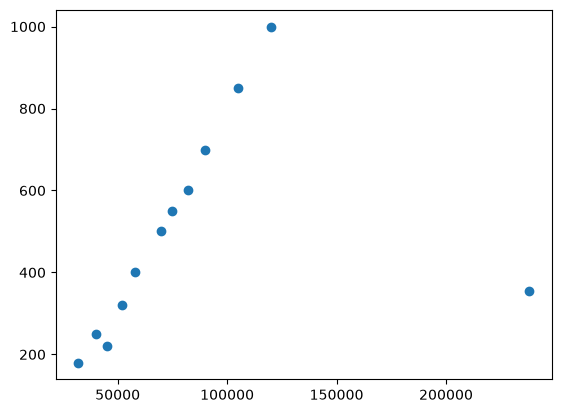

In [88]:
plt.scatter(df['Annual Income ($)'], df['Monthly Spending ($)'])

In [89]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df)
y_predicted

array([1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0], dtype=int32)

In [90]:
km.cluster_centers_

array([[3.42857143e+01, 5.31428571e+04, 1.85714286e+00, 3.45714286e+02],
       [2.60000000e+01, 2.38000000e+05, 3.00000000e+00, 3.55000000e+02],
       [5.00000000e+01, 9.92500000e+04, 4.00000000e+00, 7.87500000e+02]])

In [91]:
df['cluster'] = y_predicted
df.head(15)

,Age,Annual Income ($),Cars Owned,Monthly Spending ($),cluster
0,26,238000,3,355,1
1,25,32000,1,180,0
2,29,40000,2,250,0
3,35,52000,2,320,0
4,38,58000,2,400,0
5,42,75000,3,550,0
6,45,82000,3,600,2
7,48,90000,4,700,2
8,52,105000,4,850,2
9,55,120000,5,1000,2


C:\Users\USER\AppData\Local\Temp\ipykernel_20976\2470203213.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


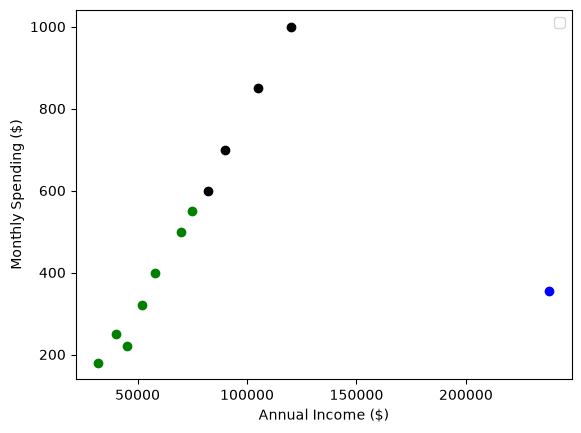

In [92]:
df0 = df[df.cluster == 0]
df1 = df[df.cluster == 1]
df2 = df[df.cluster == 2]

plt.scatter(df0['Annual Income ($)'], df0['Monthly Spending ($)'], color='green')
plt.scatter(df1['Annual Income ($)'], df1['Monthly Spending ($)'], color='blue')
plt.scatter(df2['Annual Income ($)'], df2['Monthly Spending ($)'], color='black')
plt.xlabel('Annual Income ($)')
plt.ylabel('Monthly Spending ($)')
plt.legend()

In [93]:
scaler = MinMaxScaler()

df['Annual Income ($)'] = scaler.fit_transform(df[['Annual Income ($)']])
df['Monthly Spending ($)'] = scaler.fit_transform(df[['Monthly Spending ($)']])

In [94]:
df

,Age,Annual Income ($),Cars Owned,Monthly Spending ($),cluster
0,26,1.000000,3,0.213415,1
1,25,0.000000,1,0.000000,0
2,29,0.038835,2,0.085366,0
3,35,0.097087,2,0.170732,0
4,38,0.126214,2,0.268293,0
5,42,0.208738,3,0.451220,0
6,45,0.242718,3,0.512195,2
7,48,0.281553,4,0.634146,2
8,52,0.354369,4,0.817073,2
9,55,0.427184,5,1.000000,2


In [95]:
km = KMeans(n_clusters=3)
y_predicted  = km.fit_predict(df[['Annual Income ($)', 'Monthly Spending ($)']])
y_predicted

array([1, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2], dtype=int32)

In [96]:
df['cluster'] = y_predicted

In [97]:
df.head()

,Age,Annual Income ($),Cars Owned,Monthly Spending ($),cluster
0,26,1.000000,3,0.213415,1
1,25,0.000000,1,0.000000,0
2,29,0.038835,2,0.085366,0
3,35,0.097087,2,0.170732,0
4,38,0.126214,2,0.268293,0


In [98]:
km.cluster_centers_

array([[0.06504854, 0.11463415],
       [1.        , 0.21341463],
       [0.28317152, 0.63414634]])

C:\Users\USER\AppData\Local\Temp\ipykernel_20976\2470203213.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


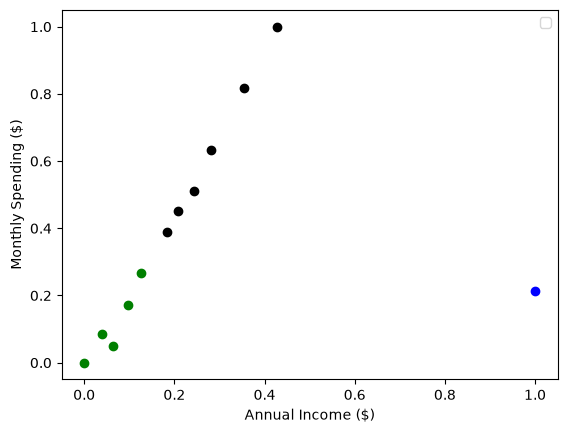

In [99]:
df0 = df[df.cluster == 0]
df1 = df[df.cluster == 1]
df2 = df[df.cluster == 2]

plt.scatter(df0['Annual Income ($)'], df0['Monthly Spending ($)'], color='green')
plt.scatter(df1['Annual Income ($)'], df1['Monthly Spending ($)'], color='blue')
plt.scatter(df2['Annual Income ($)'], df2['Monthly Spending ($)'], color='black')
plt.xlabel('Annual Income ($)')
plt.ylabel('Monthly Spending ($)')
plt.legend()

**Elbow Plot**

In [100]:
sse = []
k_range = range(1,10)

for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(df[['Annual Income ($)', 'Monthly Spending ($)']])
    sse.append(km.inertia_)

Text(0, 0.5, 'SSE')

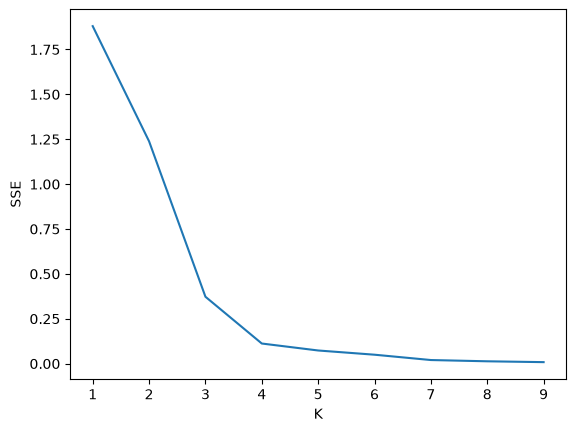

In [101]:
plt.plot(k_range, sse)
plt.xlabel('K')
plt.ylabel('SSE')